In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install requests pandas spacy matplotlib seaborn plotly -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 115.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import json
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
import requests
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
DATA_PATH = '/content/drive/MyDrive/EACL NEW DATA/EACL_26-HateSpeechDataset.json'
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)
print(f"Loaded {len(data)} samples")

Loaded 3296 samples


In [ ]:
HURTLEX_URL = "https://raw.githubusercontent.com/valeriobasile/hurtlex/master/lexica/EN/1.2/hurtlex_EN.tsv"
HURTLEX_PATH = "/content/hurtlex_EN.tsv"

In [ ]:
print("Building curated identity lexicon...")

identity_lexicon = {
    'Racial/Ethnic': [
        # Groups
        'black', 'blacks', 'african', 'african american', 'afro',
        'white', 'whites', 'caucasian',
        'asian', 'asians', 'chinese', 'japanese', 'korean',
        'hispanic', 'hispanics', 'latino', 'latinos', 'latina', 'latinas',
        'mexican', 'mexicans',
        'arab', 'arabs', 'middle eastern',
        'indian', 'indians',
        # Racialized terms
        'thug', 'thugs', 'ghetto', 'hood', 'urban',
        'blm', 'black lives matter', 'all lives matter',
        'white supremacy', 'white nationalist', 'kkk'
    ],

    'Religious': [
        # Groups
        'muslim', 'muslims', 'islam', 'islamic', 'islamist',
        'jew', 'jews', 'jewish', 'judaism',
        'christian', 'christians', 'christianity',
        'hindu', 'hindus', 'buddhist', 'buddhists',
        'catholic', 'catholics', 'protestant',
        # Religious concepts
        'sharia', 'jihad', 'jihadi', 'jihadist',
        'zionist', 'zionists', 'zionism',
        'infidel', 'infidels', 'kafir', 'kuffar',
        # Antisemitic dog whistles
        'soros', 'rothschild', 'globalist', 'globalists',
        'zog', 'aipac', 'mossad',
        'holohoax', 'holocaust denial'
    ],

    'Women/Gender': [
        'woman', 'women', 'female', 'females',
        'girl', 'girls', 'lady', 'ladies',
        'feminist', 'feminists', 'feminism', 'feminazi',
        'wife', 'wives', 'mother', 'mothers',
        'metoo', 'me too',
        # Slurs
        'bitch', 'slut', 'whore', 'hoe', 'thot'
    ],

    'LGBTQ+': [
        'gay', 'gays', 'homosexual', 'homosexuals',
        'lesbian', 'lesbians',
        'trans', 'transgender', 'transsexual', 'transexual',
        'lgbt', 'lgbtq', 'lgbtq+', 'lgbtqia',
        'queer', 'queers',
        'bisexual', 'bisexuals',
        'nonbinary', 'non-binary', 'genderqueer',
        'groomer', 'groomers', 'gender ideology',
        'pronouns', 'preferred pronouns'
    ],

    'National Origin': [
        'immigrant', 'immigrants', 'immigration', 'immigrate',
        'refugee', 'refugees', 'asylum seeker', 'asylum',
        'migrant', 'migrants', 'migration',
        'illegal alien', 'illegal aliens', 'illegals',
        'border', 'deportation', 'deport', 'deported',
        'foreigner', 'foreigners', 'outsider', 'outsiders'
    ],

    'Disability': [
        # ONLY actual disability slurs - nothing generic!
        'retard', 'retarded', 'retardation',
        'autistic', 'autism', 'autist',
        'disabled', 'disability', 'handicapped',
        'cripple', 'crippled',
        'spaz', 'spastic',
        'gimp',
        'vegetable',  # Used for severe disability
        'downs syndrome', 'down syndrome'
    ],

    'Dehumanization': [
        # Animal metaphors
        'animal', 'animals', 'beast', 'beasts',
        'vermin', 'rodent', 'rodents', 'rat', 'rats',
        'cockroach', 'cockroaches', 'insect', 'insects',
        'parasite', 'parasites', 'parasitic',
        'plague', 'disease', 'cancer',
        'savage', 'savages', 'barbarian', 'barbarians',
        'subhuman', 'sub-human', 'inhuman',
        'ape', 'apes', 'monkey', 'monkeys',
        'dog', 'dogs', 'pig', 'pigs', 'swine'
    ]
}

Building curated identity lexicon...


In [ ]:

for category in identity_lexicon:
    identity_lexicon[category] = list(set([
        term.lower().strip()
        for term in identity_lexicon[category]
    ]))

for category, terms in identity_lexicon.items():
    print(f"{category:20s}: {len(terms):3d} terms")

primary_lexicon = identity_lexicon

Racial/Ethnic       :  37 terms
Religious           :  39 terms
Women/Gender        :  23 terms
LGBTQ+              :  26 terms
National Origin     :  22 terms
Disability          :  17 terms
Dehumanization      :  35 terms


In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
def detect_identity_groups(text, lexicon, use_ner=True):
    """
    Detect identity groups mentioned/targeted in text

    Args:
        text (str): Input text to analyze
        lexicon (dict): Dictionary of {category: [terms]}
        use_ner (bool): Whether to use NER for group mentions

    Returns:
        dict: {
            'groups': list of detected identity groups,
            'matches': dict of {category: [matched_terms]}
        }
    """

    if not text or not isinstance(text, str):
        return {'groups': [], 'matches': {}}

    text_lower = text.lower()
    detected_groups = set()
    match_details = defaultdict(set)


    identity_lexicon = {
        'Racial/Ethnic': [],
        'Religious': [],
        'LGBTQ+': [],
        'Women/Gender': [],
        'Disability': [],
        'National Origin': []
    }

    # Add terms from base lexicon (filtered)
    ALLOWED_CATEGORIES = [
        'Racial/Ethnic', 'Religious', 'LGBTQ+',
        'Women/Gender', 'Disability', 'National Origin',
        'Dehumanization'  # Animal metaphors
    ]

    for cat, terms in lexicon.items():
        if cat in ALLOWED_CATEGORIES:
            identity_lexicon[cat] = list(set(terms))  # De-duplicate

    # ============================================
    # STEP 2: AUGMENT WITH ESSENTIAL TERMS
    # ============================================

    # National Origin (immigration-related)
    identity_lexicon['National Origin'].extend([
        'immigrant', 'immigrants', 'immigration', 'immigrate',
        'refugee', 'refugees', 'asylum seeker', 'asylum',
        'migrant', 'migrants', 'migration',
        'illegal alien', 'illegal aliens', 'illegals',
        'border', 'deportation', 'deport', 'deported',
        'foreigner', 'foreigners', 'outsider', 'outsiders'
    ])

    # Racial/Ethnic
    identity_lexicon['Racial/Ethnic'].extend([
        'black', 'blacks', 'african', 'african american', 'afro',
        'white', 'whites', 'caucasian',
        'asian', 'asians', 'chinese', 'japanese', 'korean',
        'hispanic', 'hispanics', 'latino', 'latinos', 'latina', 'latinas',
        'mexican', 'mexicans',
        'arab', 'arabs', 'middle eastern',
        'indian', 'indians',
        # Racialized terms
        'thug', 'thugs', 'ghetto', 'hood', 'urban',
        'blm', 'black lives matter', 'all lives matter',
        'white supremacy', 'white nationalist', 'kkk'
    ])

    # Religious
    identity_lexicon['Religious'].extend([
        'muslim', 'muslims', 'islam', 'islamic', 'islamist',
        'jew', 'jews', 'jewish', 'judaism',
        'christian', 'christians', 'christianity',
        'hindu', 'hindus', 'buddhist', 'buddhists',
        'catholic', 'catholics', 'protestant',
        # Religious concepts/slurs
        'sharia', 'jihad', 'jihadi', 'jihadist',
        'zionist', 'zionists', 'zionism',
        'infidel', 'infidels', 'kafir', 'kuffar',
        # Antisemitic dog whistles
        'soros', 'rothschild', 'globalist', 'globalists',
        'zog', 'aipac', 'mossad',
        'holohoax', 'holocaust denial'
    ])

    # Women/Gender
    identity_lexicon['Women/Gender'].extend([
        'woman', 'women', 'female', 'females',
        'girl', 'girls', 'lady', 'ladies',
        'feminist', 'feminists', 'feminism', 'feminazi',
        'wife', 'wives', 'mother', 'mothers',
        'metoo', 'me too'
    ])

    # LGBTQ+
    identity_lexicon['LGBTQ+'].extend([
        'gay', 'gays', 'homosexual', 'homosexuals',
        'lesbian', 'lesbians',
        'trans', 'transgender', 'transsexual', 'transexual',
        'lgbt', 'lgbtq', 'lgbtq+', 'lgbtqia',
        'queer', 'queers',
        'bisexual', 'bisexuals',
        'nonbinary', 'non-binary', 'genderqueer',
        # Anti-LGBTQ+ terms
        'groomer', 'groomers', 'gender ideology',
        'pronouns', 'preferred pronouns'
    ])

    # Disability
    identity_lexicon['Disability'].extend([
        'autistic', 'autism', 'autist',
        'disabled', 'disability', 'handicapped',
        'cripple', 'crippled', "retard",
        'mentally ill', 'mental illness'
    ])

    # Terms that cause too many false positives
    BLACKLIST = {
        # Generic terms
        'people', 'person', 'man', 'men', 'guy', 'guys',
        'one', 'ones', 'other', 'others', 'thing', 'things',
        'someone', 'anyone', 'everyone',

        # Generic descriptors
        'bad', 'good', 'evil', 'wrong', 'right', 'ugly',

        # Crime-related (too context-dependent)
        'criminal', 'criminals', 'crime', 'crimes',
        'rapist', 'rapists', 'rape',
        'murderer', 'killer', 'thief', 'robber',
        'dealer', 'dealers', 'drug dealer',

        # Generic insults
        'idiot', 'stupid', 'dumb', 'moron',
        'loser', 'losers', 'failure',

        # Too short/ambiguous
        'a', 'an', 'the', 'is', 'are', 'was', 'were',
        'it', 'its', 'he', 'she', 'his', 'her',

        'animal', 'beast', 'creature',
        'child', 'children', 'kid', 'kids',
        'old', 'young', 'new'
    }

    # Clean all categories
    for category in identity_lexicon:
        identity_lexicon[category] = [
            term.lower().strip()
            for term in identity_lexicon[category]
            if term.lower().strip() not in BLACKLIST
            and len(term.strip()) >= 3  # At least 3 characters
        ]
        # De-duplicate
        identity_lexicon[category] = list(set(identity_lexicon[category]))

    for category, terms in identity_lexicon.items():
        for term in terms:
            if not term:  # Skip empty strings
                continue

            # Multi-word terms: use substring match
            if ' ' in term:
                if term in text_lower:
                    detected_groups.add(category)
                    match_details[category].add(term)

            else:
                pattern = r'\b' + re.escape(term) + r's?\b'

                if re.search(pattern, text_lower):
                    detected_groups.add(category)
                    match_details[category].add(term)

    if use_ner and nlp:
        try:
            doc = nlp(text[:1000])

            for ent in doc.ents:
                ent_lower = ent.text.lower()

                if ent.label_ in ['NORP', 'GPE', 'ORG']:

                    # Religious groups
                    if any(word in ent_lower for word in
                           ['muslim', 'islam', 'jew', 'jewish', 'christian', 'hindu', 'buddhist', 'catholic']):
                        detected_groups.add('Religious')
                        match_details['Religious'].add(f"NER:{ent.text}")

                    # Racial/Ethnic
                    elif any(word in ent_lower for word in
                             ['black', 'white', 'asian', 'african', 'hispanic', 'latino', 'arab', 'chinese']):
                        detected_groups.add('Racial/Ethnic')
                        match_details['Racial/Ethnic'].add(f"NER:{ent.text}")

                    # National origin
                    elif any(word in ent_lower for word in
                             ['mexican', 'chinese', 'russian', 'american', 'immigrant', 'refugee']):
                        detected_groups.add('National Origin')
                        match_details['National Origin'].add(f"NER:{ent.text}")

        except Exception:
            pass

    return {
        'groups': sorted(list(detected_groups)),
        'matches': {cat: sorted(list(matches))[:5] for cat, matches in match_details.items()}
    }

In [ ]:
# Initialize results storage
all_results = []

print(f"\nProcessing {len(data)} posts...")

# Process each post
for i, sample in enumerate(data):
    # Progress indicator
    if (i + 1) % 500 == 0:
        print(f"  Processed {i + 1}/{len(data)} posts...")

    # Detect identity groups
    result = detect_identity_groups(sample['text'], primary_lexicon, use_ner=True)

    # Store result
    all_results.append({
        'sample_id': sample['sample_id'],
        'text_preview': sample['text'][:150] + '...',
        'identity_groups': result['groups'],
        'num_groups': len(result['groups']),
        'matches': result['matches']
    })

print(f"\nProcessed all {len(data)} posts")

results_df = pd.DataFrame(all_results)


Processing 3296 posts...
  Processed 500/3296 posts...
  Processed 1000/3296 posts...
  Processed 1500/3296 posts...
  Processed 2000/3296 posts...
  Processed 2500/3296 posts...
  Processed 3000/3296 posts...

Processed all 3296 posts


In [ ]:
# Count occurrences of each identity group
identity_counter = Counter()

for groups in results_df['identity_groups']:
    identity_counter.update(groups)

# Convert to DataFrame for easier manipulation
identity_stats = pd.DataFrame([
    {'Identity Group': group, 'Count': count}
    for group, count in identity_counter.most_common()
])

# Add percentages
identity_stats['Percentage'] = (identity_stats['Count'] / len(data) * 100).round(1)

# Sort by count
identity_stats = identity_stats.sort_values('Count', ascending=False)

print("\nIDENTITY GROUP DISTRIBUTION")
print("-" * 70)
print(identity_stats.to_string(index=False))


IDENTITY GROUP DISTRIBUTION
----------------------------------------------------------------------
 Identity Group  Count  Percentage
      Religious   1142        34.6
National Origin    962        29.2
  Racial/Ethnic    661        20.1
 Dehumanization    558        16.9
   Women/Gender    376        11.4
         LGBTQ+    157         4.8
     Disability     30         0.9


In [ ]:
print("INTERSECTIONALITY ANALYSIS")

# Distribution of number of groups per post
group_count_dist = results_df['num_groups'].value_counts().sort_index()

print("\nPosts by Number of Identity Groups Targeted:")
for num_groups, count in group_count_dist.items():
    pct = (count / len(data) * 100)
    print(f"  {num_groups} groups: {count:4d} posts ({pct:5.1f}%)")

# Coverage statistics
posts_with_groups = (results_df['num_groups'] > 0).sum()
coverage_pct = (posts_with_groups / len(data) * 100)

print(f"\nCoverage: {posts_with_groups}/{len(data)} posts ({coverage_pct:.1f}%) contain detectable identity markers")

INTERSECTIONALITY ANALYSIS

Posts by Number of Identity Groups Targeted:
  0 groups:  825 posts ( 25.0%)
  1 groups: 1334 posts ( 40.5%)
  2 groups:  882 posts ( 26.8%)
  3 groups:  232 posts (  7.0%)
  4 groups:   23 posts (  0.7%)

Coverage: 2471/3296 posts (75.0%) contain detectable identity markers


In [ ]:
print("TOP 10 IDENTITY GROUP COMBINATIONS")
# Get combinations (as tuples)
combinations = results_df['identity_groups'].apply(lambda x: tuple(sorted(x)) if x else ('None',))
combination_counts = combinations.value_counts().head(10)

for combo, count in combination_counts.items():
    pct = (count / len(data) * 100)
    combo_str = " + ".join(combo) if combo != ('None',) else "No identity groups"
    print(f"{combo_str:60s}: {count:4d} posts ({pct:4.1f}%)")

TOP 10 IDENTITY GROUP COMBINATIONS
No identity groups                                          :  825 posts (25.0%)
Religious                                                   :  414 posts (12.6%)
National Origin                                             :  320 posts ( 9.7%)
National Origin + Religious                                 :  262 posts ( 7.9%)
Racial/Ethnic                                               :  215 posts ( 6.5%)
Dehumanization                                              :  184 posts ( 5.6%)
Women/Gender                                                :  161 posts ( 4.9%)
Racial/Ethnic + Religious                                   :  136 posts ( 4.1%)
Dehumanization + Religious                                  :   95 posts ( 2.9%)
National Origin + Racial/Ethnic                             :   86 posts ( 2.6%)


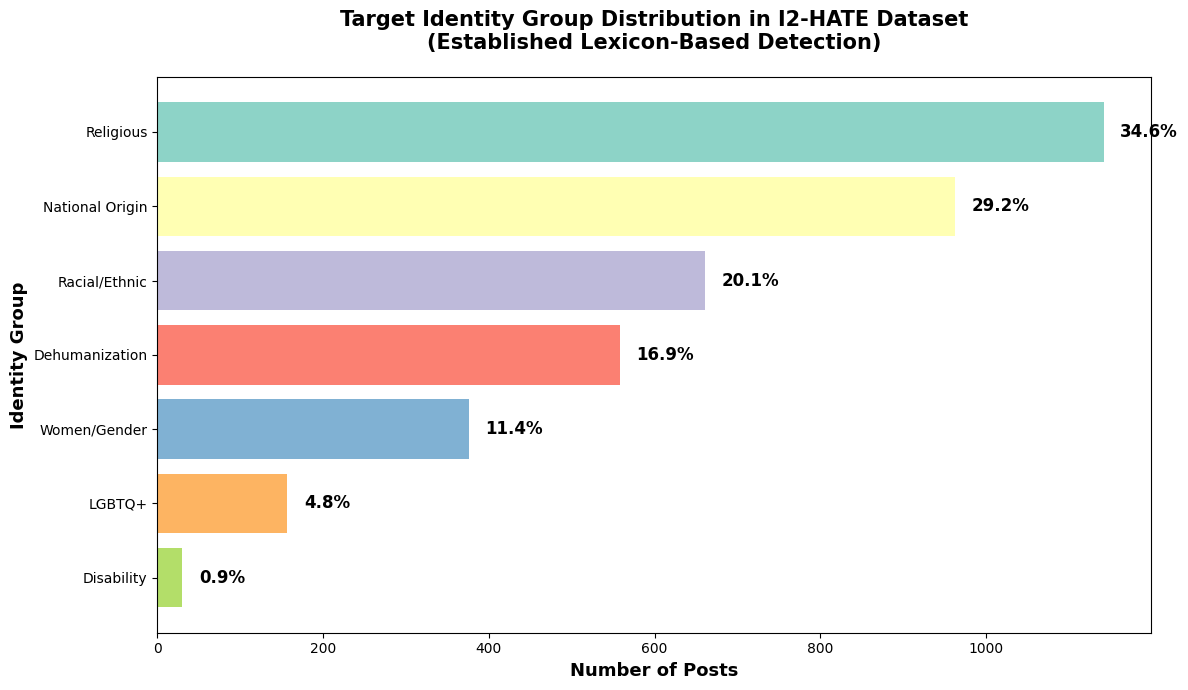

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

groups = identity_stats['Identity Group'].tolist()
counts = identity_stats['Count'].tolist()
percentages = identity_stats['Percentage'].tolist()

# Create color palette
colors = plt.cm.Set3(range(len(groups)))

bars = ax.barh(groups, counts, color=colors)

ax.set_xlabel('Number of Posts', fontsize=13, fontweight='bold')
ax.set_ylabel('Identity Group', fontsize=13, fontweight='bold')
ax.set_title('Target Identity Group Distribution in I2-HATE Dataset\n(Established Lexicon-Based Detection)',
             fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add percentage labels
for i, (group, count, pct) in enumerate(zip(groups, counts, percentages)):
    ax.text(count + 20, i, f'{pct:.1f}%',
            va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

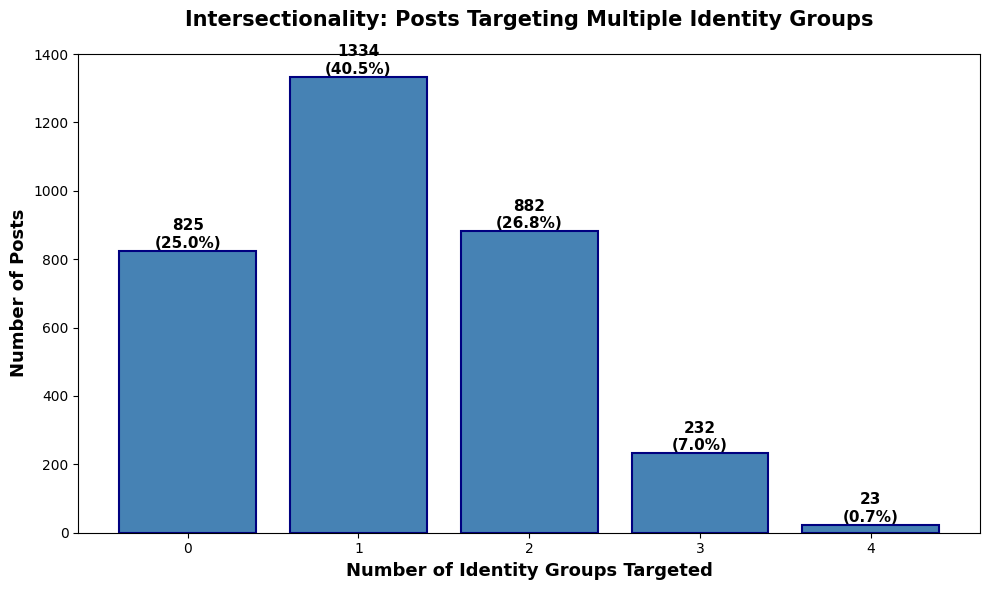

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_groups = list(group_count_dist.index)
group_counts = list(group_count_dist.values)

bars = ax.bar(num_groups, group_counts, color='steelblue', edgecolor='navy', linewidth=1.5)

ax.set_xlabel('Number of Identity Groups Targeted', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Posts', fontsize=13, fontweight='bold')
ax.set_title('Intersectionality: Posts Targeting Multiple Identity Groups',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(num_groups)

# Add value labels on bars
for bar, count in zip(bars, group_counts):
    height = bar.get_height()
    pct = (count / len(data) * 100)
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# See which Disability terms match most
from collections import Counter

disability_matches = []
for result in all_results:
    if 'Disability' in result['matches']:
        disability_matches.extend(result['matches']['Disability'])

print("Top 20 Disability matches:")
for term, count in Counter(disability_matches).most_common(20):
    print(f"{term:20s}: {count:4d} posts")

Top 20 Disability matches:
mentally ill        :    8 posts
mental illness      :    6 posts
vegetable           :    4 posts
autist              :    3 posts
cripple             :    3 posts
autistic            :    2 posts
disabled            :    2 posts
autism              :    1 posts
crippled            :    1 posts
